In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision.datasets import CIFAR10

In [4]:
#Datasets and DataLoaders
from torch.utils.data import DataLoader
from torchvision.transforms import transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = CIFAR10(root="./data", train=False, download=True, transform=transform)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [00:19<00:00, 8.59MB/s]


In [5]:
trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
test_loader = DataLoader(testset, batch_size=64)

### Build the CNN 

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), #kernel_size=2, stride=2

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(4*4*128, 256),
            nn.ReLU(),

            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1) #flattening
        x = self.fc_layers(x)

        return x

In [12]:
model = CNN()

In [13]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

In [16]:
train_losses = []
val_losses = []

epochs = 10

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0

    for images, labels in trainloader:
        optimizer.zero_grad()

        outputs = model.forward(images) #FP
        loss = criterion(outputs, labels) #loss fnx
        loss.backward() #BP
        optimizer.step() #params update

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(trainloader)
    train_losses.append(epoch_train_loss)

    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model.forward(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"for epoch {epoch+1}/{epochs}, train loss={epoch_train_loss}, val loss={epoch_val_loss}")
        

for epoch 1/10, train loss=0.9456990650090416, val loss=0.8979160785675049
for epoch 2/10, train loss=0.7519708427093218, val loss=0.8146640658378601
for epoch 3/10, train loss=0.6269571036481492, val loss=0.7337284088134766
for epoch 4/10, train loss=0.5251016464951398, val loss=0.8065037131309509
for epoch 5/10, train loss=0.43693699293276844, val loss=0.7849618196487427
for epoch 6/10, train loss=0.3530905316667179, val loss=0.7780486345291138
for epoch 7/10, train loss=0.27895364788410915, val loss=0.9145759344100952
for epoch 8/10, train loss=0.22014668084147487, val loss=0.9439659118652344
for epoch 9/10, train loss=0.17630001514568885, val loss=1.027213215827942
for epoch 10/10, train loss=0.13946538965415467, val loss=1.1352615356445312


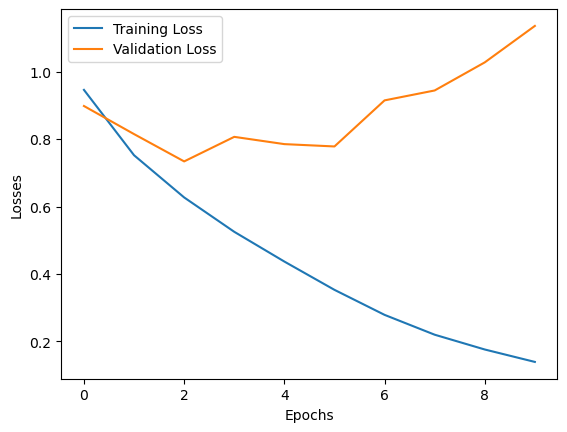

In [18]:
import matplotlib.pyplot as plt
import pandas as pd
loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})
plt.plot(loss_df["Training Loss"], label="Training Loss")
plt.plot(loss_df["Validation Loss"], label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [20]:
#Evaluate our CNN
correct_labels = 0
total_labels = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model.forward(images)
        _, predicted = torch.max(outputs, 1)

        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy: {correct_labels / total_labels * 100}")

accuracy: 75.24


In [21]:
torchvision.datasets

<module 'torchvision.datasets' from 'C:\\Users\\HP\\AppData\\Roaming\\Python\\Python313\\site-packages\\torchvision\\datasets\\__init__.py'>